# SUSY: 4.5 million training rows → a 100,000-row ML sample

Use RapidMatch to select **exactly 100,000 distinct source records** while preserving the observed signal/background proportions and checking all **18 predictors**. This follows the configuration → SQL summaries → representation plots workflow in `AB_Test.ipynb`.

[UCI SUSY](https://archive.ics.uci.edu/dataset/279/susy) contains 5 million simulated collision events: 8 low-level detector features and 10 derived features. `label=1` is a supersymmetric signal and `label=0` is background. Following the published convention, reserve the **last 500,000 rows** as a test set before calculating bins or selecting training records.

**First run:** downloads approximately 880 MB compressed and prepares disk-backed data. Allow additional working disk space for Parquet and DuckDB; exact full-population checks can take substantial time. Run HIGGS and SUSY sequentially. Later runs reuse fingerprint-validated caches.

Use a Python 3.11+ notebook kernel with the repository dependencies: `pip install -e ".[notebook]"`. Install `ipykernel` separately if your notebook editor needs it. Start the kernel in this repository or a subdirectory.

Source: Whiteson, D. (2014), *SUSY*, UCI Machine Learning Repository, [doi:10.24432/C54606](https://doi.org/10.24432/C54606), CC BY 4.0. See also [Baldi et al. (2014)](https://arxiv.org/abs/1402.4735).

In [1]:
from pathlib import Path
from importlib.metadata import version
import json
import os
import platform
import sys
import time
import tomllib

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents, Path.cwd() / 'RapidMatch']
            if (p / 'rapidmatch').is_dir() and (p / 'notebook_downsample.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from rapidmatch import random_downsample
from notebook_downsample import download_dataset, prepare_dataset, plot_distributions, export_sample

VERSIONS = {name: version(name) for name in ['duckdb', 'pyarrow', 'numpy', 'pandas', 'matplotlib']}
VERSIONS['python'] = platform.python_version()
VERSIONS['rapidmatch'] = tomllib.loads((ROOT / 'pyproject.toml').read_text())['project']['version']
display(pd.Series(VERSIONS, name='version').to_frame())

,version
duckdb,1.5.5
pyarrow,25.0.1
numpy,2.5.3
pandas,3.0.6
matplotlib,3.11.2
python,3.12.1
rapidmatch,0.1.0


## 1. Dataset and reproducible settings
Feature names follow the UCI file order. `source_row_id` is an identity, never an ML predictor or stratification variable. Override `RAPIDMATCH_NOTEBOOK_CACHE` to put large artifacts on another disk. Set `ALLOW_DOWNLOAD=False` for cache-only operation.

In [2]:
DATASET = 'SUSY'
SOURCE_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz'
TOTAL_ROWS, TEST_ROWS = 5_000_000, 500_000
TRAIN_ROWS = TOTAL_ROWS - TEST_ROWS
SAMPLE_SIZE, SEED = 100_000, 42
ALLOW_DOWNLOAD = True
DUCKDB_THREADS, PLOT_ROWS = 2, 50_000
CACHE_DIR = Path(os.environ.get('RAPIDMATCH_NOTEBOOK_CACHE', ROOT / '.cache' / 'ml_downsample')) / DATASET.lower()
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RAW_PATH = CACHE_DIR / f'{DATASET}.csv.gz'
X_VARS = [
    'lepton1_pt', 'lepton1_eta', 'lepton1_phi', 'lepton2_pt', 'lepton2_eta', 'lepton2_phi',
    'missing_energy_magnitude', 'missing_energy_phi',
    'met_rel', 'axial_met', 'm_r', 'm_tr_2', 'r', 'mt2', 's_r', 'm_delta_r', 'dphi_r_b', 'cos_theta_r1',
]
STRATIFY_VARS = ['lepton1_pt', 'missing_energy_magnitude', 'm_r', 'mt2']
assert len(X_VARS) == 18 and SAMPLE_SIZE < TRAIN_ROWS
print(f'{DATASET}: {TRAIN_ROWS:,} training rows → {SAMPLE_SIZE:,} ({TRAIN_ROWS / SAMPLE_SIZE:.0f}× reduction)')
print('Cache:', CACHE_DIR.resolve())

SUSY: 4,500,000 training rows → 100,000 (45× reduction)
Cache: D:\RapidSampler\temp\RapidMatch\.cache\ml_downsample\susy


## 2. Acquire the complete population and reserve the test set
The shared helper streams the gzip download, records a local SHA-256 fingerprint, parses the headerless CSV with explicit column types, and creates ordered Parquet partitions through file-backed DuckDB. It rejects incomplete row counts, invalid labels, and nonfinite features. The fingerprint detects later cache changes; it is not a publisher-provided checksum.

IDs are 1-based source line numbers. Training IDs are `1..4,500,000`; test IDs are `4,500,001..5,000,000`. The test set is checked only for structural separation and is never supplied to the sampler or used to tune settings.

In [3]:
source_info = download_dataset(SOURCE_URL, RAW_PATH, allow_download=ALLOW_DOWNLOAD)
TRAIN_PATH, TEST_PATH, preparation_info = prepare_dataset(
    RAW_PATH, CACHE_DIR, X_VARS, total_rows=TOTAL_ROWS, test_rows=TEST_ROWS, source=source_info,
)
display(pd.Series(source_info, name='source').to_frame())

Using cached source: d:\RapidSampler\temp\RapidMatch\.cache\ml_downsample\susy\SUSY.csv.gz
Using validated training/test Parquet cache


,source
url,https://archive.ics.uci.edu/ml/machine-learnin...
bytes,922377711
sha256,be56cb5598da8ece4b13912230ee713bab8b3431a7d118...


In [4]:
with duckdb.connect() as con:
    con.execute("SET memory_limit = '2GB'")
    con.execute(f'SET threads = {DUCKDB_THREADS}')
    con.execute('SET temp_directory = ?', [str(CACHE_DIR / 'profile_spill')])
    for path, expected_n, first_id, last_id in [
        (TRAIN_PATH, TRAIN_ROWS, 1, TRAIN_ROWS),
        (TEST_PATH, TEST_ROWS, TRAIN_ROWS + 1, TOTAL_ROWS),
    ]:
        actual = con.execute('SELECT COUNT(*), COUNT(DISTINCT source_row_id), '
                             'MIN(source_row_id), MAX(source_row_id) FROM read_parquet(?)', [str(path)]).fetchone()
        assert actual == (expected_n, expected_n, first_id, last_id), actual
    population_classes = con.execute('SELECT label, COUNT(*) AS population_rows FROM read_parquet(?) '
                                     'GROUP BY label ORDER BY label', [str(TRAIN_PATH)]).df()
    assert set(population_classes.label) == {0, 1}
    expressions = [expression for name in X_VARS for expression in (
        f'MIN("{name}")', f'MAX("{name}")', f'AVG("{name}")',
        f'COUNT(*) FILTER (WHERE NOT COALESCE(isfinite("{name}"), FALSE))',
    )]
    values = con.execute('SELECT ' + ', '.join(expressions) + ' FROM read_parquet(?)', [str(TRAIN_PATH)]).fetchone()
feature_profile = pd.DataFrame([values[i:i + 4] for i in range(0, len(values), 4)],
                               index=X_VARS, columns=['minimum', 'maximum', 'mean', 'nonfinite_rows'])
assert feature_profile.nonfinite_rows.sum() == 0
population_classes['population_share'] = population_classes.population_rows / TRAIN_ROWS
display(population_classes, feature_profile)

,label,population_rows,population_share
0,0.0,2441602,0.542578
1,1.0,2058398,0.457422


,minimum,maximum,mean,nonfinite_rows
lepton1_pt,2.548815e-01,20.553450,1.000196,0
lepton1_eta,-2.102927e+00,2.101605,-0.000106,0
lepton1_phi,-1.734789e+00,1.734839,-0.000078,0
lepton2_pt,4.285860e-01,33.035622,0.999280,0
lepton2_eta,-2.059306e+00,2.059721,-0.000220,0
lepton2_phi,-1.734202e+00,1.734686,0.000103,0
missing_energy_magnitude,2.598711e-04,21.068876,0.999796,0
missing_energy_phi,-1.727117e+00,1.740689,0.000250,0
met_rel,8.645641e-08,23.386438,1.001389,0
axial_met,-1.671863e+01,20.487904,-0.000192,0


## 3. Select exactly 100,000 unique training records
The observed class proportions are preserved with largest-remainder integer quotas—not forced to 50:50. Within each class, four illustrative features are split into four population-derived quantile bins, giving at most 512 class-feature groups. Every remaining predictor is a check variable.

There are **54 required feature checks**: 18 overall and 18 per class. The default KS threshold is 0.05 (a maximum empirical CDF difference, not a p-value). Class-label JS is descriptive; quotas have their own exact invariant. The ID is excluded from all feature checks.

Selection is deterministic for fixed input/order, seed, and versions. A failed balance check still returns exactly 100,000 records; inspect the result before calling it accepted. No automatic retry, threshold relaxation, or sample-size increase occurs.

In [5]:
settings = dict(
    sample_size=SAMPLE_SIZE, label_col='label', stratify_vars=STRATIFY_VARS,
    check_vars=[name for name in X_VARS if name not in STRATIFY_VARS],
    n_bins=4, random_state=SEED, ks_threshold=0.05, js_threshold=0.10,
    check_by_label=True, duckdb_threads=DUCKDB_THREADS, max_report_rows=1000,
)
started = time.perf_counter()
result = random_downsample(str(TRAIN_PATH), **settings, work_dir=str(CACHE_DIR / 'sampling_work'), keep_db=False)
sampling_seconds = time.perf_counter() - started
summary = result.report.summary
print(f'Sampling + full-population checks: {sampling_seconds / 60:.2f} minutes')
display(pd.Series(summary, name='value').to_frame())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sampling + full-population checks: 2.36 minutes


,value
n_population,4500000
requested_rows,100000
sampled_rows,100000
count_invariants_passed,True
class_budgets_passed,True
random_state,42
label_col,label
stratify_vars,"[lepton1_pt, missing_energy_magnitude, m_r, mt2]"
check_vars,"[lepton1_eta, lepton1_phi, lepton2_pt, lepton2..."
checked_features,"[lepton1_pt, missing_energy_magnitude, m_r, mt..."


In [6]:
sample_df = result.sample.to_pandas()  # Only the 100k selected records.
assert len(sample_df) == SAMPLE_SIZE
assert sample_df.source_row_id.nunique() == SAMPLE_SIZE
assert np.unique(result.row_ids.to_numpy()).size == SAMPLE_SIZE
assert sample_df.source_row_id.between(1, TRAIN_ROWS).all()
assert (sample_df.source_row_id % 1 == 0).all()
assert set(sample_df.label) == {0, 1}
assert set(sample_df.columns) == {'source_row_id', 'label', *X_VARS}
classes = result.report.classes.to_pandas()
classes['target'] = classes.label.map(lambda value: int(json.loads(value)[0]))
actual_counts = sample_df.groupby('label').size()
for row in classes.itertuples():
    assert actual_counts.loc[row.target] == row.allocated_rows == row.sampled_rows
    assert abs(row.rounding_deviation) < 1
    assert row.n_population == population_classes.set_index('label').loc[row.target, 'population_rows']
balance = result.report.balance.to_pandas()
required = balance[balance.required].copy()
assert summary['feature_checks'] == len(required) == 3 * len(X_VARS)
assert set(required.variable) == set(X_VARS)
assert required.groupby('variable').size().eq(3).all()
assert not any(summary[key] for key in ['classes_truncated', 'strata_truncated', 'balance_truncated'])
print(f'Exact count, unique identities, training-only membership and class quotas: PASS ({SAMPLE_SIZE:,} rows)')
print('Feature acceptance:', summary['balance_status'].upper())
display(classes, required.sort_values('statistic', ascending=False))
display(pd.DataFrame(result.report.recommendations))

Exact count, unique identities, training-only membership and class quotas: PASS (100,000 rows)
Feature acceptance: PASS


,label,n_population,ideal_quota,allocated_rows,sampled_rows,population_share,sample_share,rounding_deviation,target
0,[0.0],2441602,54257.822222,54258,54258,0.542578,0.54258,0.177778,0
1,[1.0],2058398,45742.177778,45742,45742,0.457422,0.45742,-0.177778,1


,variable,role,scope,label,kind,statistic,threshold,n_population,n_sample,n_valid_population,n_valid_sample,population_missing_rate,sample_missing_rate,status,required
14,lepton1_phi,feature,within_label,[1.0],ks,0.004569,0.05,2058398,45742,2058398,45742,0.0,0.0,pass,True
7,dphi_r_b,feature,within_label,[0.0],ks,0.004444,0.05,2441602,54258,2441602,54258,0.0,0.0,pass,True
35,m_tr_2,feature,within_label,[1.0],ks,0.004232,0.05,2058398,45742,2058398,45742,0.0,0.0,pass,True
22,lepton2_phi,feature,within_label,[0.0],ks,0.004225,0.05,2441602,54258,2441602,54258,0.0,0.0,pass,True
31,m_r,feature,within_label,[0.0],ks,0.004173,0.05,2441602,54258,2441602,54258,0.0,0.0,pass,True
11,lepton1_eta,feature,within_label,[1.0],ks,0.004148,0.05,2058398,45742,2058398,45742,0.0,0.0,pass,True
29,m_delta_r,feature,within_label,[1.0],ks,0.004105,0.05,2058398,45742,2058398,45742,0.0,0.0,pass,True
52,s_r,feature,within_label,[0.0],ks,0.003942,0.05,2441602,54258,2441602,54258,0.0,0.0,pass,True
13,lepton1_phi,feature,within_label,[0.0],ks,0.003837,0.05,2441602,54258,2441602,54258,0.0,0.0,pass,True
6,dphi_r_b,feature,overall,NaN,ks,0.003719,0.05,4500000,100000,4500000,100000,0.0,0.0,pass,True


,setting,proposed_value,reason,evidence,tradeoff
0,sample_size,NaN,13 feature groups received zero rows after pro...,measured_allocation,A larger user-requested sample can improve rep...
1,n_bins,2.0,Coarser feature bins may reduce zero-allocatio...,untested_suggestion,Coarser groups can hide distribution differenc...


## 4. Inspect class shares and feature representation
The KS table and bars use **exact comparisons against all training rows**. Histogram/ECDF panels use seeded, bounded subsets (at most 50,000 rows per group) for visualization. Their curves are approximate; the exact statistic in each title comes from the report. Histograms crop to the central 99% display range; the checks include the tails.

Passing these marginal and within-class checks does not establish identical joint distributions or guarantee downstream model accuracy.

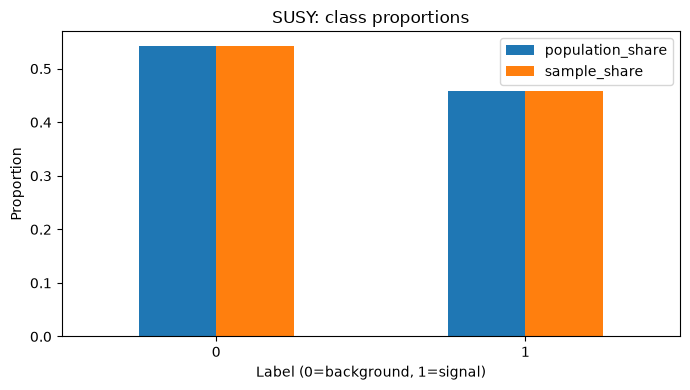

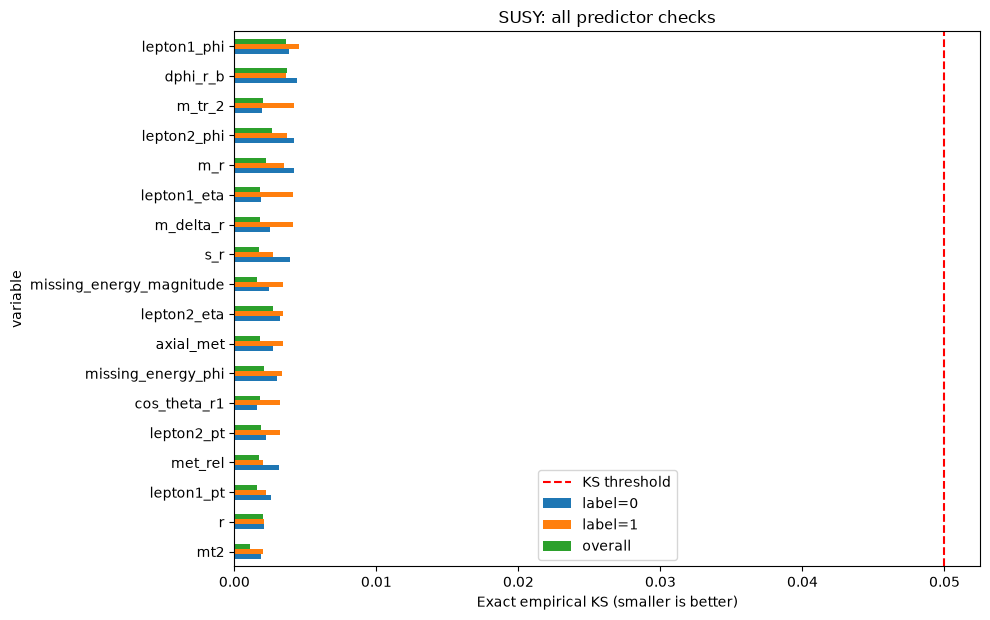

In [7]:
class_figure, ax = plt.subplots(figsize=(7, 4))
classes.set_index('target')[['population_share', 'sample_share']].sort_index().plot.bar(ax=ax, rot=0)
ax.set(xlabel='Label (0=background, 1=signal)', ylabel='Proportion', title=f'{DATASET}: class proportions')
class_figure.tight_layout()
plt.show()

required['comparison'] = required.apply(
    lambda row: 'overall' if row.scope == 'overall' else f'label={int(json.loads(row.label)[0])}', axis=1,
)
ks_table = required.pivot(index='variable', columns='comparison', values='statistic')
ks_table = ks_table.loc[ks_table.max(axis=1).sort_values().index]
ks_figure, ax = plt.subplots(figsize=(10, max(6, len(X_VARS) * 0.35)))
ks_table.plot.barh(ax=ax)
ax.axvline(settings['ks_threshold'], color='red', linestyle='--', label='KS threshold')
ax.set(xlabel='Exact empirical KS (smaller is better)', title=f'{DATASET}: all predictor checks')
ax.legend()
ks_figure.tight_layout()
plt.show()

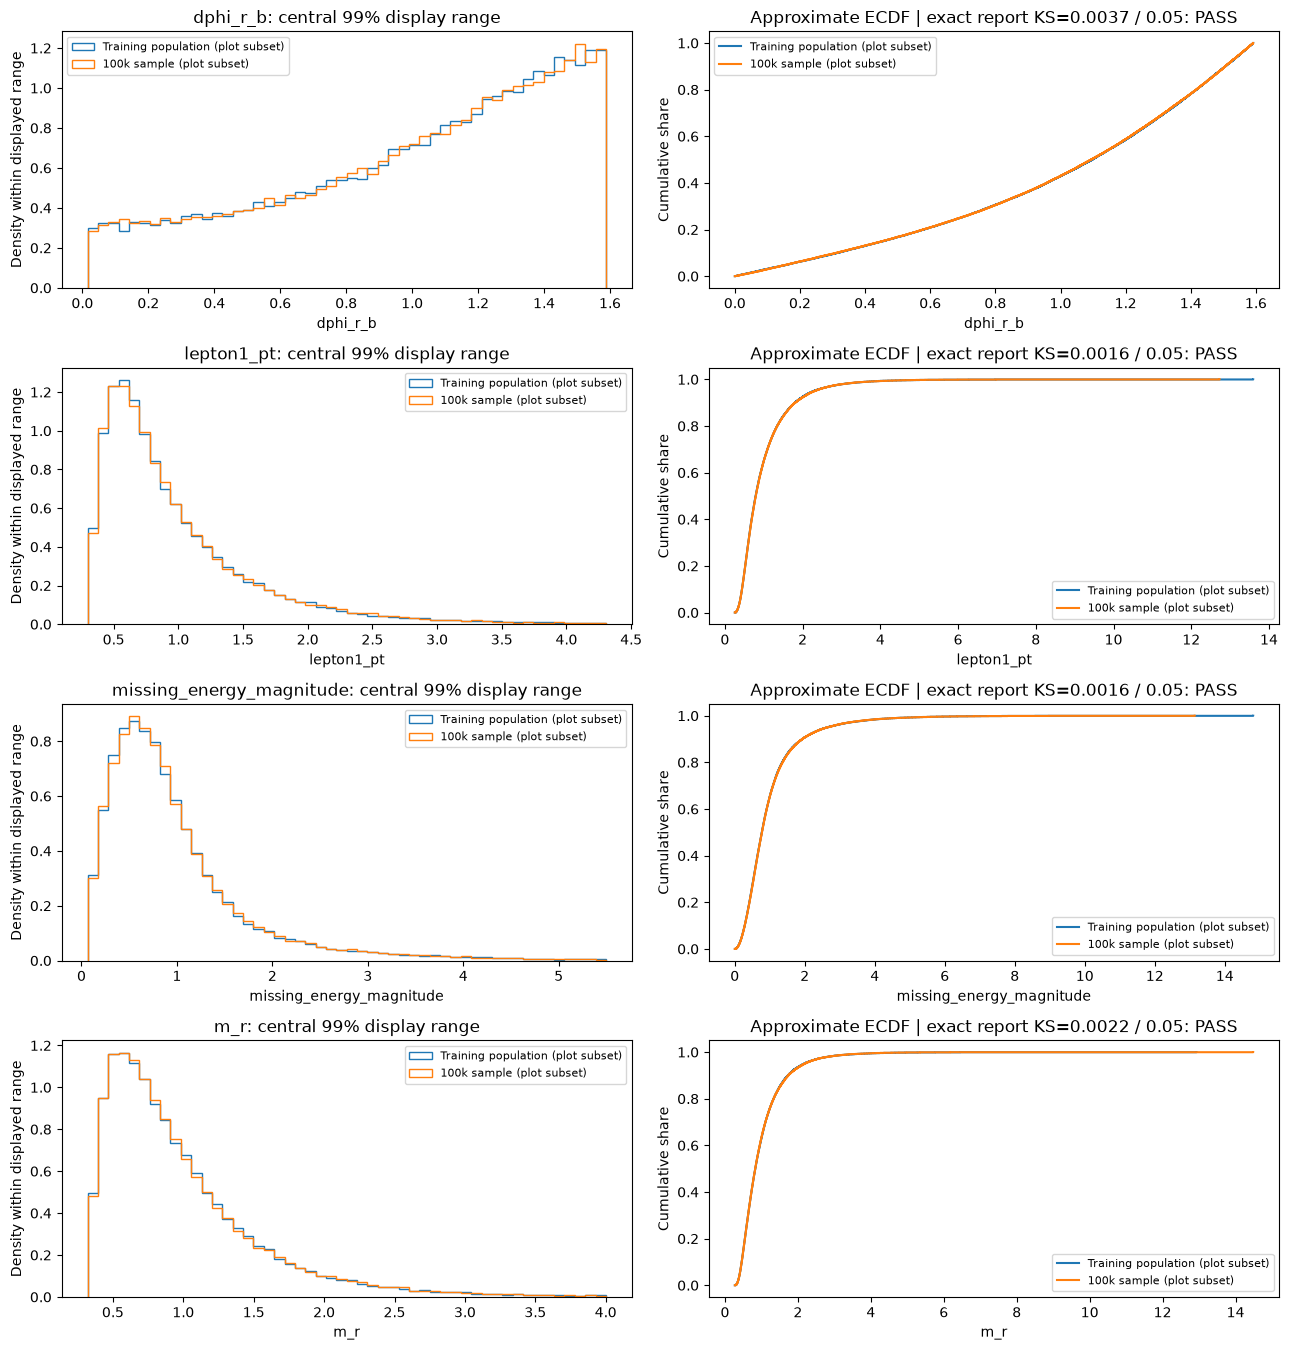

In [8]:
# Include the worst overall check, plus representative low/high-level stratification features.
worst_feature = required[required.scope == 'overall'].sort_values('statistic', ascending=False).iloc[0].variable
plot_features = list(dict.fromkeys([worst_feature, *STRATIFY_VARS]))[:4]
distribution_figure = plot_distributions(TRAIN_PATH, result.sample, plot_features, balance, seed=SEED, plot_rows=PLOT_ROWS)
plt.show()

## 5. Export the sample, reports, and provenance
Each run gets its own output folder. A passing sample is named `training_sample_100k.parquet`; a failed/unavailable assessment is saved as `candidate_100k.parquet` with `accepted=false` in the manifest. Both retain exactly 100,000 rows. The helper restores integer ID/label types and verifies Parquet readback.

The manifest records source/prepared-file fingerprints, sampling settings, versions, timing, and selected-ID fingerprint. Replay with the same input files, order, seed, and versions to reproduce the selection. Recommendations are reported, not applied automatically.

In [9]:
exported_sample, RUN_DIR = export_sample(result, CACHE_DIR / 'outputs', {
    'dataset': DATASET, 'source': source_info, 'preparation': preparation_info,
    'settings': settings, 'versions': VERSIONS, 'sampling_seconds': sampling_seconds,
})
for name, figure in [('class_shares', class_figure), ('feature_ks', ks_figure), ('distributions', distribution_figure)]:
    figure.savefig(RUN_DIR / f'{name}.png', dpi=140, bbox_inches='tight')
display(pd.DataFrame([{'file': path.name, 'MiB': path.stat().st_size / 1024**2}
                      for path in sorted(RUN_DIR.iterdir())]))
print('Output directory:', RUN_DIR.resolve())

Accepted sample: d:\RapidSampler\temp\RapidMatch\.cache\ml_downsample\susy\outputs\20261004T134404031950Z\training_sample_100k.parquet


,file,MiB
0,class_shares.png,0.022890
1,distributions.png,0.260391
2,feature_ks.png,0.056564
3,manifest.json,0.002366
4,report.json,0.236845
5,training_sample_100k.parquet,11.313831


Output directory: D:\RapidSampler\temp\RapidMatch\.cache\ml_downsample\susy\outputs\20261004T134404031950Z


In [10]:
X_train = y_train = None
if summary['balance_status'] == 'pass':
    X_train = exported_sample.select(X_VARS)
    y_train = exported_sample['label']
    print(f'Training-ready Arrow X: {X_train.num_rows:,} × {X_train.num_columns}; y: {len(y_train):,}')
else:
    print('Inspect failed/unavailable checks before using this candidate for training.')
print('Reserved test data:', TEST_PATH)
print('Fit future preprocessing on training data only; use the test set for final evaluation.')

Training-ready Arrow X: 100,000 × 18; y: 100,000
Reserved test data: d:\RapidSampler\temp\RapidMatch\.cache\ml_downsample\susy\test.parquet
Fit future preprocessing on training data only; use the test set for final evaluation.
